# Взятие FFT сигнала, затем перестановка частей спектра

In [73]:
from scipy.io import wavfile
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

#### fft

In [74]:
def fft_forward(x_time: np.ndarray) -> np.ndarray:
    return np.fft.fft(x_time)

In [75]:
def fft_inverse(X_freq: np.ndarray) -> np.ndarray:
    return np.real(np.fft.ifft(X_freq))

## main

In [76]:
input_wav = "../dataset/test_sounds/pets.wav"

fs, x = wavfile.read(input_wav)
if x.ndim > 1:
    x = x[:, 0]
x = x.astype(np.float64)

original_len = len(x)

# нормализуем в [-1..1], чтобы метрики были сопоставимы
x = x / (np.max(np.abs(x)) + 1e-12)

# базовый FFT один раз
X = fft_forward(x)

In [77]:
X = fft_forward(x)
x_rec = fft_inverse(X)[:original_len]

# запись
x_rec_norm = x_rec / (np.max(np.abs(x_rec)) + 1e-12)
wavfile.write("./assets/fft_clean.wav", fs, (x_rec_norm * 32767).astype(np.int16))

## метрики

In [78]:
import numpy as np
import pandas as pd

def _align(a: np.ndarray, b: np.ndarray):
    n = min(len(a), len(b))
    return a[:n].astype(float), b[:n].astype(float)

def mse(a: np.ndarray, b: np.ndarray) -> float:
    a, b = _align(a, b)
    e = a - b
    return float(np.mean(e * e))

def snr_db(ref: np.ndarray, test: np.ndarray) -> float:
    ref, test = _align(ref, test)
    noise = ref - test
    p_sig = np.mean(ref * ref) + 1e-12
    p_noi = np.mean(noise * noise) + 1e-12
    return float(10.0 * np.log10(p_sig / p_noi))

def psnr_db(ref: np.ndarray, test: np.ndarray, peak: float = 1.0) -> float:
    m = mse(ref, test) + 1e-12
    return float(10.0 * np.log10((peak * peak) / m))

def corrcoef(a: np.ndarray, b: np.ndarray) -> float:
    a, b = _align(a, b)
    a = a - np.mean(a)
    b = b - np.mean(b)
    denom = (np.std(a) * np.std(b)) + 1e-12
    return float(np.mean(a * b) / denom)

def shannon_entropy(x: np.ndarray, bins: int = 256) -> float:
    x = x.astype(float)
    m = np.max(np.abs(x)) + 1e-12
    x = x / m
    hist, _ = np.histogram(x, bins=bins, range=(-1, 1), density=False)
    p = hist.astype(float)
    p = p / (np.sum(p) + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def rms_level(x: np.ndarray) -> float:
    x = x.astype(float)
    return float(np.sqrt(np.mean(x * x) + 1e-12))

def spectral_entropy(x: np.ndarray, fs: int, eps: float = 1e-12) -> float:
    """
    Энтропия по частотному распределению энергии.
    Берём P(f) = |X(f)|^2 / sum(|X(f)|^2).
    """
    _, mag = _rfft_mag(x, fs)          # |X|
    p = (mag * mag)                    # |X|^2
    p = p / (np.sum(p) + eps)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def _rfft_mag(x: np.ndarray, fs: int):
    x = x.astype(float)
    win = np.hanning(len(x))
    X = np.fft.rfft(x * win)
    mag = np.abs(X) + 1e-12
    freqs = np.fft.rfftfreq(len(x), d=1.0/fs)
    return freqs, mag

def spectral_flatness(x: np.ndarray, fs: int) -> float:
    _, mag = _rfft_mag(x, fs)
    gmean = np.exp(np.mean(np.log(mag)))
    amean = np.mean(mag)
    return float(gmean / (amean + 1e-12))

def spectral_centroid(x: np.ndarray, fs: int) -> float:
    freqs, mag = _rfft_mag(x, fs)
    return float(np.sum(freqs * mag) / (np.sum(mag) + 1e-12))

def spectral_bandwidth(x: np.ndarray, fs: int) -> float:
    freqs, mag = _rfft_mag(x, fs)
    c = np.sum(freqs * mag) / (np.sum(mag) + 1e-12)
    var = np.sum(((freqs - c) ** 2) * mag) / (np.sum(mag) + 1e-12)
    return float(np.sqrt(var))

def lsd_db(ref: np.ndarray, test: np.ndarray, fs: int) -> float:
    ref, test = _align(ref, test)
    _, mag_r = _rfft_mag(ref, fs)
    _, mag_t = _rfft_mag(test, fs)
    lr = 20.0 * np.log10(mag_r)
    lt = 20.0 * np.log10(mag_t)
    return float(np.mean(np.abs(lr - lt)))

def compute_metrics(name: str, ref: np.ndarray, sig: np.ndarray, fs: int, base: dict) -> dict:
    out = {
        "name": name,

        "entropy(y)": shannon_entropy(sig),
        "spec_entropy(y)": spectral_entropy(sig, fs),

        "corr(x,y)": corrcoef(ref, sig),
        "mse(x,y)": mse(ref, sig),
        "snr_db(x,y)": snr_db(ref, sig),
        "psnr_db(x,y)": psnr_db(ref, sig, peak=1.0),
        "lsd_db(x,y)": lsd_db(ref, sig, fs),

        "rms(y)": rms_level(sig),

        "flatness(y)": spectral_flatness(sig, fs),
        "centroid(y)_Hz": spectral_centroid(sig, fs),
        "bandwidth(y)_Hz": spectral_bandwidth(sig, fs),
    }

    # дельты относительно оригинала
    out["d_rms"] = out["rms(y)"] - base["rms(x)"]
    out["d_spec_entropy"] = out["spec_entropy(y)"] - base["spec_entropy(x)"]
    out["d_centroid_Hz"] = out["centroid(y)_Hz"] - base["centroid(x)_Hz"]
    out["d_bandwidth_Hz"] = out["bandwidth(y)_Hz"] - base["bandwidth(x)_Hz"]
    out["d_flatness"] = out["flatness(y)"] - base["flatness(x)"]

    return out

results = {}

In [79]:
base = {
    "rms(x)": rms_level(x),
    "spec_entropy(x)": spectral_entropy(x, fs),
    "centroid(x)_Hz": spectral_centroid(x, fs),
    "bandwidth(x)_Hz": spectral_bandwidth(x, fs),
    "flatness(x)": spectral_flatness(x, fs),
}

## Скремблинг 1: Инверсия спектра

In [ ]:
def encrypt_invert(X: np.ndarray) -> np.ndarray:
    return X[::-1]

X_inv = encrypt_invert(X)
x_inv = fft_inverse(X_inv)[:original_len]

x_inv_norm = x_inv / (np.max(np.abs(x_inv)) + 1e-12)
wavfile.write("./assets/enc/encfft_inverted.wav", fs, (x_inv_norm * 32767).astype(np.int16))

## Decrypt: inversion (та же операция)

In [81]:
X_inv_dec = encrypt_invert(X_inv)
x_inv_dec = fft_inverse(X_inv_dec)[:original_len]

x_inv_dec_norm = x_inv_dec / (np.max(np.abs(x_inv_dec)) + 1e-12)
wavfile.write("./assets/dec/fft_inverted_dec.wav", fs, (x_inv_dec_norm * 32767).astype(np.int16))

In [82]:
results["fft_invert_enc"] = compute_metrics("fft_invert_enc", x, x_inv, fs, base)
results["fft_invert_dec"] = compute_metrics("fft_invert_dec", x, x_inv_dec, fs, base)

## Скремблинг 2: Полный shuffle бин (перестановка всех коэффициентов)

In [83]:
perm = np.random.permutation(len(X)).astype(np.int64)
perm.tofile("key.bin")

def encrypt_shuffle(X: np.ndarray, perm: np.ndarray) -> np.ndarray:
    return X[perm]

X_shuf = encrypt_shuffle(X, perm)
x_shuf = fft_inverse(X_shuf)[:original_len]

x_shuf_norm = x_shuf / (np.max(np.abs(x_shuf)) + 1e-12)
wavfile.write("./assets/enc/fft_shuffle.wav", fs, (x_shuf_norm * 32767).astype(np.int16))

## Decrypt: shuffle (обратная перестановка)

In [84]:
perm_loaded = np.fromfile("key.bin", dtype=np.int64)
inv_perm = np.argsort(perm_loaded)

def decrypt_shuffle(X: np.ndarray, inv_perm: np.ndarray) -> np.ndarray:
    return X[inv_perm]

X_shuf_dec = decrypt_shuffle(X_shuf, inv_perm)
x_shuf_dec = fft_inverse(X_shuf_dec)[:original_len]

x_shuf_dec_norm = x_shuf_dec / (np.max(np.abs(x_shuf_dec)) + 1e-12)
wavfile.write("./assets/dec/fft_shuffle_dec.wav", fs, (x_shuf_dec_norm * 32767).astype(np.int16))

In [85]:
results["fft_shuffle_enc"] = compute_metrics("fft_shuffle_enc", x, x_shuf, fs, base)
results["fft_shuffle_dec"] = compute_metrics("fft_shuffle_dec", x, x_shuf_dec, fs, base)

### Скремблинг 3: Блочная перестановка спектра

In [ ]:
Nblocks = 180
key_file = "key.bin"

L = len(X)
pad = (-L) % Nblocks
if pad:
    X_pad = np.pad(X, (0, pad), mode="constant")
else:
    X_pad = X

B = len(X_pad) // Nblocks  # размер блока

blocks = X_pad.reshape(Nblocks, B)

key = np.random.permutation(Nblocks).astype(np.int64)
key.tofile(key_file)

shuffled = np.empty_like(blocks)
for i in range(Nblocks):
    shuffled[key[i]] = blocks[i]

X_blk = shuffled.reshape(-1)[:L]
x_blk = fft_inverse(X_blk)[:original_len]

x_blk_norm = x_blk / (np.max(np.abs(x_blk)) + 1e-12)
wavfile.write("./assets/enc/fft_block_shuffle.wav", fs, (x_blk_norm * 32767).astype(np.int16))

### Decrypt: block shuffle по key.bin

In [87]:
key_loaded = np.fromfile(key_file, dtype=np.int64)

L = len(X_blk)
pad = (-L) % Nblocks
if pad:
    Xb_pad = np.pad(X_blk, (0, pad), mode="constant")
else:
    Xb_pad = X_blk

B = len(Xb_pad) // Nblocks
blocks_enc = Xb_pad.reshape(Nblocks, B)

# обратная операция к shuffled[key[i]] = blocks[i]
# то есть blocks[i] = shuffled[key[i]]
restored = np.empty_like(blocks_enc)
for i in range(Nblocks):
    restored[i] = blocks_enc[key_loaded[i]]

X_blk_dec = restored.reshape(-1)[:len(X)]
x_blk_dec = fft_inverse(X_blk_dec)[:original_len]

x_blk_dec_norm = x_blk_dec / (np.max(np.abs(x_blk_dec)) + 1e-12)
wavfile.write("./assets/dec/fft_block_shuffle_dec.wav", fs, (x_blk_dec_norm * 32767).astype(np.int16))

In [88]:
results["fft_block_shuffle_enc"] = compute_metrics("fft_block_shuffle_enc", x, x_blk, fs, base)
results["fft_block_shuffle_dec"] = compute_metrics("fft_block_shuffle_dec", x, x_blk_dec, fs, base)

рассчет шифрованного/дешифрованного

In [ ]:
DATASET_DIR = "../../dataset/test_sounds"
OUT_ENC_INVERT = "./assets/enc/enc_invert"
OUT_ENC_ALL_SHUFFLE = "./assets/enc/enc_all_shuffle"
OUT_ENC_BLOCK_SHUFFLE = "./assets/enc/enc_block_shuffle"
OUT_DEC_BLOCK_SHUFFLE = "./assets/dec/dec_invert"
OUT_DEC_ALL_SHUFFLE = "./assets/dec/dec_all_shuffle"
OUT_DEC_BLOCK_SHUFFLE = "./assets/dec/dec_block_shuffle"

IN_PATTERN = "test_sound{i:1d}.wav"
OUT_PATTERN = "test_sound{i:1d}_{tag}.wav"

os.makedirs(OUT_ENC_SIMPLE_DIR, exist_ok=True)
os.makedirs(OUT_DEC_SIMPLE_DIR, exist_ok=True)
os.makedirs(OUT_ENC_SPLIT_DIR, exist_ok=True)
os.makedirs(OUT_DEC_SPLIT_DIR, exist_ok=True)

N_FILES = 23

freq_hi_simple = 2632.0
freq_lo_split = 500.0
freq_hi_split = 2500.0

for i in range(1, N_FILES + 1):
    in_path = os.path.join(DATASET_DIR, f"test_sound{i:1d}.wav")

    fs, data = wavfile.read(in_path)
    x = to_mono_float(data)

    # --- SIMPLE ---
    simple_enc = simple_process(x, fs, freq_hi=freq_hi_simple)
    simple_dec = simple_process(simple_enc, fs, freq_hi=freq_hi_simple)

    write_wav(os.path.join(OUT_ENC_SIMPLE_DIR, f"test_sound{i:1d}_simple_enc.wav"), fs, simple_enc)
    write_wav(os.path.join(OUT_DEC_SIMPLE_DIR, f"sample_{i:1d}_simple_dec.wav"), fs, simple_dec)

    # --- SPLIT ---
    if freq_lo_split >= freq_hi_split:
        raise ValueError("freq_lo must be < freq_hi")
    if fs < 2.0 * freq_hi_split:
        raise ValueError("sample rate must be at least 2*freq_hi (Nyquist)")

    split_enc = split_process(x, fs, freq_lo=freq_lo_split, freq_hi=freq_hi_split)
    split_dec = split_process(split_enc, fs, freq_lo=freq_lo_split, freq_hi=freq_hi_split)

    write_wav(os.path.join(OUT_ENC_SPLIT_DIR, f"sample_{i:1d}_split_enc.wav"), fs, split_enc)
    write_wav(os.path.join(OUT_DEC_SPLIT_DIR, f"sample_{i:1d}_split_dec.wav"), fs, split_dec)

### вывод метрик

,entropy(y),spec_entropy(y),d_spec_entropy,"corr(x,y)","mse(x,y)","snr_db(x,y)","psnr_db(x,y)","lsd_db(x,y)",rms(y),d_rms,flatness(y),d_flatness,centroid(y)_Hz,d_centroid_Hz,bandwidth(y)_Hz,d_bandwidth_Hz
fft_invert_enc,4.262744,14.107584,0.010423,-0.005605,0.01687,-1.519907,17.728837,3.798508,0.069972,-0.039062,0.032886,0.002056,2434.564015,26.59337,2410.233728,-23.680709
fft_invert_dec,5.094409,14.097161,0.0,1.0,0.0,100.751255,120.0,0.0,0.109034,0.0,0.03083,-0.0,2407.970645,0.0,2433.914437,0.0
fft_shuffle_enc,6.807981,15.773407,1.676246,-0.000257,0.01783,-1.760241,17.488504,33.604814,0.077053,-0.031981,0.479495,0.448666,11024.68468,8616.714035,6354.092882,3920.178444
fft_shuffle_dec,5.094409,14.097161,0.0,1.0,0.0,100.751255,120.0,0.0,0.109034,0.0,0.03083,-0.0,2407.970645,0.0,2433.914437,0.0
fft_block_shuffle_enc,4.805485,14.927478,0.830317,0.000631,0.017824,-1.758801,17.489944,31.924353,0.077111,-0.031923,0.118074,0.087245,10262.740744,7854.770099,6349.161663,3915.247226
fft_block_shuffle_dec,5.094409,14.097161,0.0,1.0,0.0,100.751255,120.0,0.0,0.109034,0.0,0.03083,-0.0,2407.970645,0.0,2433.914437,0.0


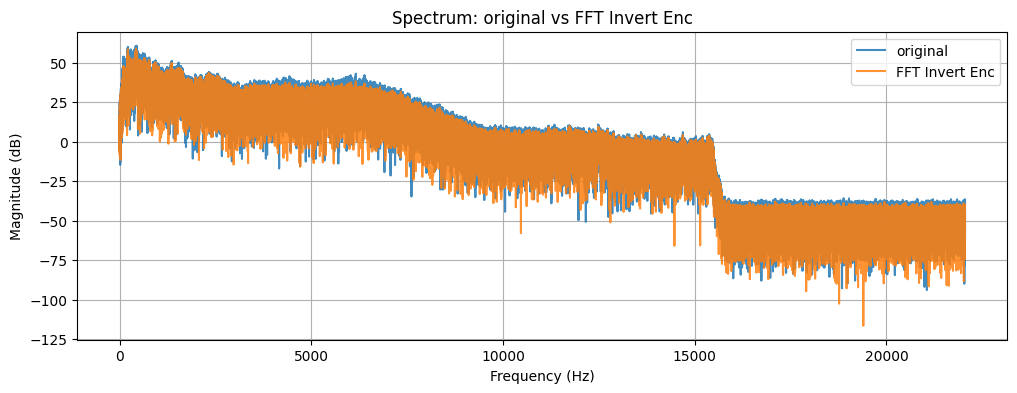

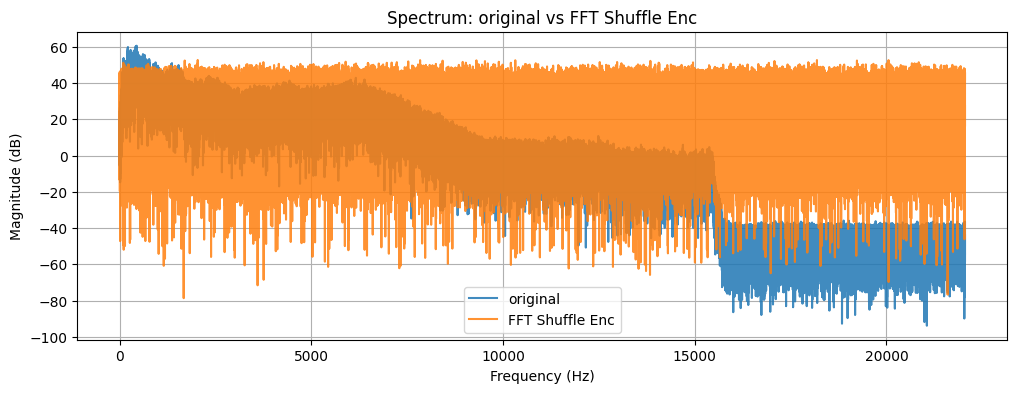

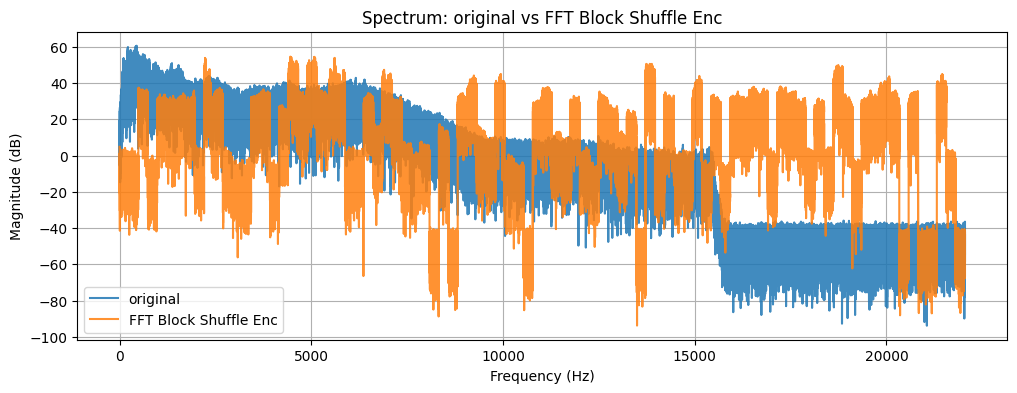

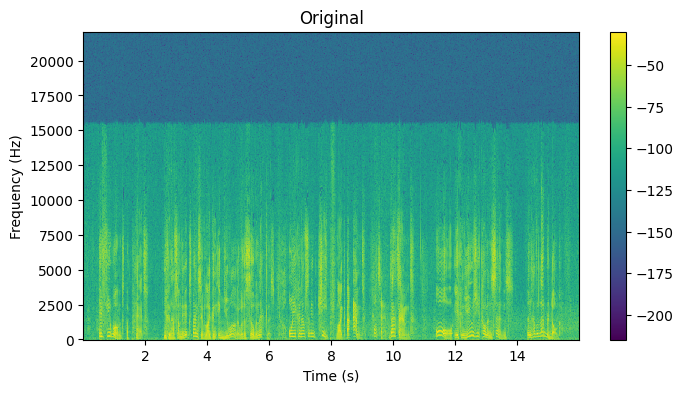

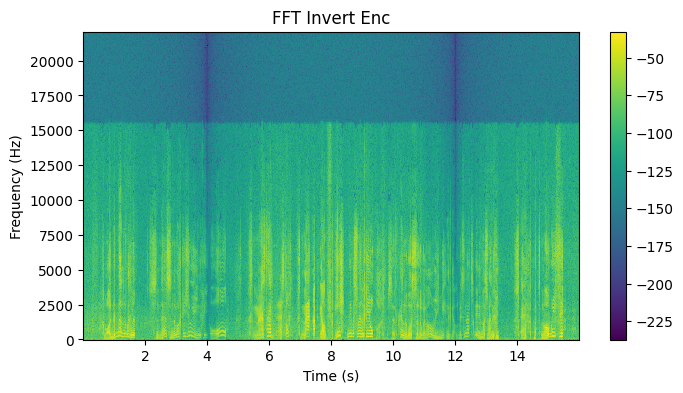

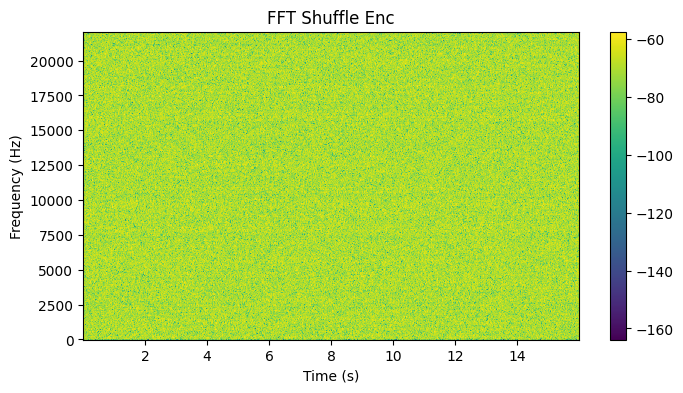

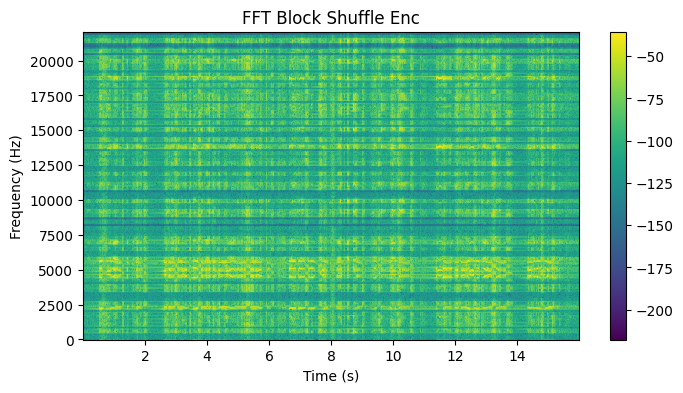

In [89]:
df = pd.DataFrame(results).T  # строки = эксперименты
df = df[[
    "entropy(y)",
    "spec_entropy(y)",
    "d_spec_entropy",

    "corr(x,y)",
    "mse(x,y)",
    "snr_db(x,y)",
    "psnr_db(x,y)",
    "lsd_db(x,y)",

    "rms(y)",
    "d_rms",

    "flatness(y)",
    "d_flatness",
    "centroid(y)_Hz",
    "d_centroid_Hz",
    "bandwidth(y)_Hz",
    "d_bandwidth_Hz",
]]
display(df)

def spectrum(x, fs):
    win = np.hanning(len(x))
    X = np.fft.rfft(x * win)
    mag = 20*np.log10(np.abs(X) + 1e-12)
    freqs = np.fft.rfftfreq(len(x), 1/fs)
    return freqs, mag

pairs = [
    ("FFT Invert Enc", x, x_inv),
    ("FFT Shuffle Enc", x, x_shuf),
    ("FFT Block Shuffle Enc", x, x_blk),
]

for title, a, b in pairs:
    f1, m1 = spectrum(a, fs)
    f2, m2 = spectrum(b, fs)

    plt.figure(figsize=(12, 4))
    plt.plot(f1, m1, label="original", alpha=0.85)
    plt.plot(f2, m2, label=title, alpha=0.85)
    plt.title(f"Spectrum: original vs {title}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_spectrogram(sig, fs, title):
    f, t, S = signal.spectrogram(
        sig,
        fs=fs,
        window="hann",
        nperseg=1024,
        noverlap=768,
        mode="magnitude",
    )
    S_db = 20*np.log10(S + 1e-12)
    plt.figure(figsize=(8,4))
    plt.pcolormesh(t, f, S_db, shading="auto")
    plt.title(title)
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

plot_spectrogram(x, fs, "Original")
plot_spectrogram(x_inv, fs, "FFT Invert Enc")
plot_spectrogram(x_shuf, fs, "FFT Shuffle Enc")
plot_spectrogram(x_blk, fs, "FFT Block Shuffle Enc")